# Policy Text Router v0.1：50条政策新闻实验

这个 Notebook 按“数据 → measure 拆分 → routing → 质量检查 → 典型案例 → 人工标注入口”的顺序展示已经跑完的结果。所有结果都已预先执行；只看输出也能理解实验过程。API Key 不在 Notebook 中。

## 步骤1：读取实验文件

先载入50条最终样本、105条 measure 路由结果、运行统计和质量检查结果。

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / 'data' / 'news_sample.csv').exists():
    raise RuntimeError('请把Notebook工作目录设为 policy_text_router_v0 项目根目录')

news = pd.read_csv(ROOT / 'data' / 'news_sample.csv')
routes = pd.read_csv(ROOT / 'output' / 'routing_results.csv')
review = pd.read_csv(ROOT / 'output' / 'results_for_review.csv')
qa = json.loads((ROOT / 'output' / 'qa_summary.json').read_text(encoding='utf-8'))
run = json.loads((ROOT / 'output' / 'run_summary.json').read_text(encoding='utf-8'))

print(f"新闻数：{len(news)}；measure数：{len(routes)}；运行错误：{qa['api_or_pipeline_errors']}")

新闻数：50；measure数：105；运行错误：0


## 步骤2：看样本覆盖

样本全部来自华尔街见闻公开7×24快讯。不是直接取最新50条，而是从历史快讯池中先做政策主体与政策动作筛选，再经过模型有效性筛选、主题均衡、标题去重和人工规则精修。

In [2]:
summary = pd.DataFrame({
    '项目': ['时间起点', '时间终点', '来源', '正文平均长度', '主题数'],
    '结果': [news['date'].min(), news['date'].max(), ', '.join(news['source'].unique()),
           round(news['content'].str.len().mean(), 1), news['candidate_theme'].nunique()]
})
display(summary)
display(news['candidate_theme'].value_counts().rename_axis('主题').to_frame('新闻数'))
display(news[['news_id','date','candidate_theme','title','url']].head(10))

,项目,结果
0,时间起点,2026-07-22T15:18:39+08:00
1,时间终点,2026-08-06T15:11:25+08:00
2,来源,华尔街见闻-7x24快讯
3,正文平均长度,183.1
4,主题数,9


,新闻数
主题,
综合政策,8
能源与环保,7
科技与制造,7
财政与税收,6
消费与民生,6
房地产,6
贸易与外部冲击,5
资本市场制度,4
货币与金融,1


,news_id,date,candidate_theme,title,url
0,3144029,2026-08-03T16:36:02+08:00,能源与环保,两部门：到2030年，核电装机约1.1亿千瓦,https://wallstreetcn.com/livenews/3144029
1,3140182,2026-07-27T17:01:39+08:00,综合政策,国务院办公厅印发《关于国务院行政复议案件处理程序的若干规定》,https://wallstreetcn.com/livenews/3140182
2,3139332,2026-07-24T16:07:04+08:00,贸易与外部冲击,商务部新闻发言人就将14家欧盟实体列入出口管制管控名单答记者问,https://wallstreetcn.com/livenews/3139332
3,3139293,2026-07-24T15:07:07+08:00,财政与税收,三部门将开展征收挥发性有机物环境保护税试点,https://wallstreetcn.com/livenews/3139293
4,3141549,2026-07-29T15:40:59+08:00,综合政策,《智能家用电器质量安全风险分类评价指南》国家标准发布,https://wallstreetcn.com/livenews/3141549
5,3141499,2026-07-29T14:26:57+08:00,消费与民生,商务部：进一步加力推动城市一刻钟便民生活圈建设,https://wallstreetcn.com/livenews/3141499
6,3145884,2026-08-06T15:11:25+08:00,科技与制造,工信部：引导民爆产能向需求集中、缺口扩大的地区转移，限制产能过剩地区产能转入,https://wallstreetcn.com/livenews/3145884
7,3139357,2026-07-24T16:49:10+08:00,资本市场制度,香港证监会优化单日杠杆及反向产品的监管框架以确保市场有序交易,https://wallstreetcn.com/livenews/3139357
8,3144033,2026-08-03T16:37:24+08:00,能源与环保,两部门：到2030年，西电东送规模超过4.2亿千瓦,https://wallstreetcn.com/livenews/3144033
9,3142301,2026-07-30T16:46:31+08:00,综合政策,国家发改委发布《电网公平开放监管办法》（公开征求意见稿）,https://wallstreetcn.com/livenews/3142301


## 步骤3：measure 拆分结果

measure 是最小政策动作单元。同一政策工具、对象和执行期下的多个数字目标合并，不再逐项拆成大量相似 measure；每条 evidence 必须逐字命中标题或正文。

In [3]:
measure_dist = routes.groupby('news_id').size().value_counts().sort_index().rename_axis('每条新闻的measure数').to_frame('新闻数')
display(measure_dist)
print('evidence逐字命中率：', f"{qa['evidence_exact_match_rate']:.0%}")
display(review[['sample_order','title','measure_id','measure_summary','evidence']].head(12))

,新闻数
每条新闻的measure数,
1,23
2,10
3,10
4,4
5,2
6,1


evidence逐字命中率： 100%


,sample_order,title,measure_id,measure_summary,evidence
0,1,两部门：到2030年，核电装机约1.1亿千瓦,M001,设定到2030年核电装机约1.1亿千瓦的量化目标,到2030年，核电装机约1.1亿千瓦
1,1,两部门：到2030年，核电装机约1.1亿千瓦,M002,推动核电规模化建设并推进新一代核电技术研发示范和推广应用,推动核电规模化建设，积极推进新一代核电技术研发示范和推广应用
2,1,两部门：到2030年，核电装机约1.1亿千瓦,M003,多措并举降低小型堆成本并加强核能综合利用和商业模式创新,多措并举降低小型堆成本，加强核能综合利用和商业模式创新
3,2,国务院办公厅印发《关于国务院行政复议案件处理程序的若干规定》,M001,印发《关于国务院行政复议案件处理程序的若干规定》并自印发之日起施行，以规范国务院行政复议案件...,日前，国务院办公厅印发《关于国务院行政复议案件处理程序的若干规定》，自印发之日起施行。
4,3,商务部新闻发言人就将14家欧盟实体列入出口管制管控名单答记者问,M001,将14家欧盟实体列入出口管制管控名单，禁止出口经营者向上述实体出口两用物项，并禁止境外组织和...,中方决定将拉法特集团等14家欧盟实体列入出口管制管控名单，禁止出口经营者向上述实体出口两用物...
5,4,三部门将开展征收挥发性有机物环境保护税试点,M001,自2027年1月1日起开展挥发性有机物环境保护税试点，将挥发性有机物全部纳入征税范围。,明确自2027年1月1日起开展征收挥发性有机物环境保护税试点，挥发性有机物将全部纳入征税范围
6,4,三部门将开展征收挥发性有机物环境保护税试点,M002,首批将印刷、化学原料和化学制品制造等八个行业纳入征收试点范围。,首批纳入征收试点范围的行业包括印刷、化学原料和化学制品制造等八个行业
7,4,三部门将开展征收挥发性有机物环境保护税试点,M003,设定挥发性有机物环境保护税税额幅度为每污染当量8元至12元，由省级政府确定具体适用税额。,挥发性有机物环境保护税的税额幅度为每污染当量8元至12元。具体适用税额由各省、自治区、直辖市...
8,5,《智能家用电器质量安全风险分类评价指南》国家标准发布,M001,发布智能家用电器质量安全风险分类评价国家标准，确立风险分类原则、指标与方法，统一评估流程与分...,市场监管总局近日批准发布《智能家用电器质量安全风险分类评价指南》（GB/T 47777—20...
9,6,商务部：进一步加力推动城市一刻钟便民生活圈建设,M001,设定2026年全国建设1万个城市一刻钟便民生活圈的量化目标并加快进度,2026年完成全国建设1万个便民生活圈的既定目标


## 步骤4：routing 分类结果

三个标签可同时为真：`all_a` 表示全市场共同环境，`style` 表示股票特征组合间的系统性差异，`industry` 表示具体行业供需、成本、产能、融资或监管约束。

,正标签measure数
全A,9
风格,5
行业,82


,measure数
industry,81
none,12
all_a,7
style,3
all_a+style+industry,1
all_a+style,1


C:\Users\CHENWE~1\AppData\Local\Temp\ipykernel_16344\589150320.py:11: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\CHENWE~1\AppData\Local\Temp\ipykernel_16344\589150320.py:11: UserWarning: Glyph 39118 (\N{CJK UNIFIED IDEOGRAPH-98CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\CHENWE~1\AppData\Local\Temp\ipykernel_16344\589150320.py:11: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\CHENWE~1\AppData\Local\Temp\ipykernel_16344\589150320.py:11: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\CHENWE~1\AppData\Local\Temp\ipykernel_16344\589150320.py:11: UserWarning: Glyph 19994 (\N{CJK UNIFIED IDEOGRAPH-4E1A}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\CHENWE~1\AppData

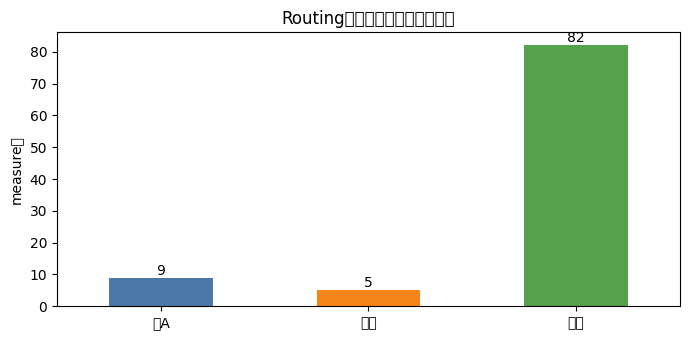

In [4]:
label_counts = pd.Series(qa['label_positive_counts']).rename({'all_a':'全A','style':'风格','industry':'行业'})
combo_counts = pd.Series(qa['route_combinations']).sort_values(ascending=False)
display(label_counts.to_frame('正标签measure数'))
display(combo_counts.to_frame('measure数'))

ax = label_counts.plot(kind='bar', color=['#4C78A8','#F58518','#54A24B'], figsize=(7,3.5), rot=0)
ax.set_title('Routing标签分布（标签可重叠）')
ax.set_ylabel('measure数')
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout(); plt.show()

## 步骤5：自动质量检查

这些检查不判断“经济含义是否一定正确”，但能保证数据与程序没有静默损坏：50条是否全部返回、schema逻辑是否一致、行业标签是否越界、evidence是否来自原文、是否仍存在高度重复的measure。

In [5]:
checks = pd.DataFrame([
    ['输入新闻=输出新闻', qa['news_input'], qa['news_output'], qa['news_input']==qa['news_output']==50],
    ['API/流程错误', 0, qa['api_or_pipeline_errors'], qa['api_or_pipeline_errors']==0],
    ['Evidence逐字命中', qa['measure_count'], qa['evidence_exact_match'], qa['evidence_exact_match']==qa['measure_count']],
    ['Schema不变量错误', 0, qa['schema_invariant_errors'], qa['schema_invariant_errors']==0],
    ['非法行业标签', 0, len(qa['invalid_industry_labels']), len(qa['invalid_industry_labels'])==0],
    ['高度相似measure对', 0, qa['near_duplicate_measure_pairs'], qa['near_duplicate_measure_pairs']==0],
], columns=['检查项','目标','实际','通过'])
display(checks)
assert checks['通过'].all()
print('全部自动检查通过。')

,检查项,目标,实际,通过
0,输入新闻=输出新闻,50,50,True
1,API/流程错误,0,0,True
2,Evidence逐字命中,105,105,True
3,Schema不变量错误,0,0,True
4,非法行业标签,0,0,True
5,高度相似measure对,0,0,True


全部自动检查通过。


## 步骤6：查看典型分类

下面每种主路由各取若干案例。`none` 不是失败，而是政策真实存在、但不应进入当前三个A股研究模块。

In [6]:
examples = (review.sort_values(['primary_route','confidence'], ascending=[True,False])
            .groupby('primary_route', group_keys=False).head(3))
display(examples[['primary_route','title','measure_summary','style_dimensions','industries','confidence','rationale']])

,primary_route,title,measure_summary,style_dimensions,industries,confidence,rationale
26,all_a,英国央行决议要点汇总,英国央行计划于9月就下一年度量化紧缩计划作出决定。,NaN,NaN,0.90,英国央行作为全球主要央行，其量化紧缩计划直接决定全球流动性供给与长期利率水平，进而通过跨境资...
33,all_a,中共中央政治局会议：深化资本市场投融资综合改革，提升资本市场韧性和信心,深化资本市场投融资综合改革以提升市场韧性和信心,NaN,NaN,0.90,该政策直接针对资本市场投融资制度进行综合改革，属于改变全市场交易制度与流动性的系统性举措，将...
39,all_a,香港与马来西亚扩大资本市场跨境准入 推进双重上市与基金互认,简化首次公开招股（IPO）双重上市框架,NaN,NaN,0.90,该政策简化跨境双重上市框架，直接改变A股跨境资金准入与上市制度环境，属于全市场共同定价环境的调整。
0,industry,两部门：到2030年，核电装机约1.1亿千瓦,设定到2030年核电装机约1.1亿千瓦的量化目标,NaN,电力设备,0.95,该政策设定了核电装机容量的具体量化目标，直接引导电力设备行业的投资与建设节奏，属于针对特定行...
1,industry,两部门：到2030年，核电装机约1.1亿千瓦,推动核电规模化建设并推进新一代核电技术研发示范和推广应用,NaN,电力设备,0.95,该政策直接针对核电行业的产能扩张与技术迭代，明确指向电力设备行业的需求与供给变化。政策未涉及...
2,industry,两部门：到2030年，核电装机约1.1亿千瓦,多措并举降低小型堆成本并加强核能综合利用和商业模式创新,NaN,电力设备,0.95,该政策直接针对核电行业（属于电力设备行业）的成本降低与商业模式创新，旨在提升该特定行业的经济...
32,multiple,中共中央政治局会议：深化资本市场投融资综合改革，提升资本市场韧性和信心,实施一揽子化债方案以稳定房地产市场并推进地方中小金融机构改革化险,quality|liquidity|volatility,房地产|银行,0.90,该政策通过化债和金融机构改革直接降低系统性金融风险，改善全市场流动性与风险偏好，属于全市场共...
85,multiple,美联储今年连续五次按兵不动，决议声明称：洛根等三人倾向于加息,维持联邦基金利率目标区间在3.5%-3.75%不变,value_growth|liquidity,NaN,0.90,美联储维持利率不变直接改变全球流动性与无风险利率环境，影响A股全市场估值定价（all_a）。...
3,none,国务院办公厅印发《关于国务院行政复议案件处理程序的若干规定》,印发《关于国务院行政复议案件处理程序的若干规定》并自印发之日起施行，以规范国务院行政复议案件...,NaN,NaN,0.95,该政策仅规范国务院内部行政复议案件的程序与监督机制，属于行政流程优化，不直接改变A股市场的流...
16,none,香港证监会优化单日杠杆及反向产品的监管框架以确保市场有序交易,强制杠杆及反向产品采用灵活杠杆结构，允许在现有上限内每日调整杠杆倍数,NaN,NaN,0.95,该政策针对香港市场的特定衍生品（杠杆及反向产品）进行监管优化，旨在提升产品风险管理的灵活性，...


## 步骤7：首轮与最终版对比

这个对比用于说明工程迭代，不是严格控制变量实验：期间既修改了prompt，也替换了10条不够典型或重复的样本。

In [7]:
def load_jsonl(path):
    return [json.loads(x) for x in path.read_text(encoding='utf-8').splitlines() if x.strip()]

base_m = load_jsonl(ROOT / 'output_baseline_v1' / 'measures.jsonl')
base_r = load_jsonl(ROOT / 'output_baseline_v1' / 'routing_results.jsonl')
base_measure_count = len(base_r)
base_exact = sum(m['evidence'] in x['news']['content'] for x in base_m for m in x['result']['measures'])
comparison = pd.DataFrame([
    ['measure数', base_measure_count, qa['measure_count']],
    ['Evidence逐字命中率', f"{base_exact/base_measure_count:.1%}", f"{qa['evidence_exact_match_rate']:.1%}"],
    ['风格正标签', sum(x['routing']['style'] for x in base_r), qa['label_positive_counts']['style']],
    ['高度相似measure对', 12, qa['near_duplicate_measure_pairs']],
    ['流程错误', 0, qa['api_or_pipeline_errors']],
], columns=['指标','首轮','最终版'])
display(comparison)

,指标,首轮,最终版
0,measure数,124,105
1,Evidence逐字命中率,92.7%,100.0%
2,风格正标签,0,5
3,高度相似measure对,12,0
4,流程错误,0,0


## 步骤8：人工标注入口

人工标注暂不代填。模板已经按一行一条 measure 展开，保留原文、模型标签和空白人工字段；下一步可以直接在 CSV 中逐条核对。

In [8]:
annotation = pd.read_csv(ROOT / 'data' / 'human_annotation_template.csv')
human_cols = [c for c in annotation.columns if c.startswith('human_')]
print('待人工标注行数：', len(annotation))
print('人工字段：', human_cols)
display(annotation[['sample_order','title','measure_summary','all_a','style','industry'] + human_cols].head())

待人工标注行数： 105
人工字段： ['human_measure_valid', 'human_all_a', 'human_style', 'human_industry', 'human_correct_industries', 'human_error_type', 'human_notes']


,sample_order,title,measure_summary,all_a,style,industry,human_measure_valid,human_all_a,human_style,human_industry,human_correct_industries,human_error_type,human_notes
0,1,两部门：到2030年，核电装机约1.1亿千瓦,设定到2030年核电装机约1.1亿千瓦的量化目标,False,False,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,两部门：到2030年，核电装机约1.1亿千瓦,推动核电规模化建设并推进新一代核电技术研发示范和推广应用,False,False,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,两部门：到2030年，核电装机约1.1亿千瓦,多措并举降低小型堆成本并加强核能综合利用和商业模式创新,False,False,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2,国务院办公厅印发《关于国务院行政复议案件处理程序的若干规定》,印发《关于国务院行政复议案件处理程序的若干规定》并自印发之日起施行，以规范国务院行政复议案件...,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3,商务部新闻发言人就将14家欧盟实体列入出口管制管控名单答记者问,将14家欧盟实体列入出口管制管控名单，禁止出口经营者向上述实体出口两用物项，并禁止境外组织和...,False,False,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 步骤9：当前结论

- 50条新闻全部被识别为政策新闻，共拆出105条独立 measure。
- 最终输出包含9条全A、5条风格、82条行业正标签；其中有2条多标签 measure，12条为 `none`。
- 自动工程检查全部通过：零错误、evidence 100%逐字命中、行业词表无越界、schema逻辑无冲突、无高度重复 measure。
- 当前结果可以作为人工标注前的 baseline，但不能直接当作“模型准确率”。最需要人工核对的是跨境政策是否真的传导到A股、风格标签是否过度解释、以及行业标签是否过宽。